# BEV Fusion Exploration (Camera + LiDAR)

In [18]:
# Core imports for data loading + plotting.
from __future__ import annotations

import json
import importlib.util
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# Consistent plotting defaults make visual comparisons easier across cells.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"

# __file__ is not available in notebooks; discover repo root by walking up.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "src" / "paths.py").exists():
        PROJECT_ROOT = candidate
        break

# Load paths.py from the exact file path to avoid stale/shadowed imports.
paths_file = PROJECT_ROOT / "src" / "paths.py"
spec = importlib.util.spec_from_file_location("project_paths", paths_file)
paths = importlib.util.module_from_spec(spec)
assert spec is not None and spec.loader is not None
spec.loader.exec_module(paths)

ZOD_MOE_DATA = paths.ZOD_MOE_DATA
OUTPUTS_DIR = paths.OUTPUTS_DIR
ORIGINAL_DATA = paths.ZOD_DINO_DATA / "train2017"

print(f"Loaded paths from: {paths_file}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"ORIGINAL_DATA: {ORIGINAL_DATA}")
print(f"OUTPUTS_DIR: {OUTPUTS_DIR}")

#first_frame_dir = ORIGINAL_DATA / "000000"
first_frame_dir = ORIGINAL_DATA / "060350"
print(f"first_frame_dir: {first_frame_dir}")

Loaded paths from: /home/edgelab/multimodal-MoE/src/paths.py
PROJECT_ROOT: /home/edgelab/multimodal-MoE
ORIGINAL_DATA: /home/edgelab/zod_dino_data/train2017
OUTPUTS_DIR: /home/edgelab/multimodal-MoE/outputs
first_frame_dir: /home/edgelab/zod_dino_data/train2017/060350


In [19]:
#helpers
def _read_json(path: Path):
    try:
        return json.loads(path.read_text())
    except Exception as e:
        print(f"Could not read JSON: {path}\n{e}")
        return None


def _iso_to_dt(s: str) -> datetime:
    # Z-suffixed timestamp helper.
    # iso format: 2021-01-01T00:00:00.000000Z
    # datetime format: 2021-01-01 00:00:00+00:00
    return datetime.fromisoformat(s.replace("Z", "+00:00"))


def find_keyframe_timestamp(frame_dir: Path, info_dict: dict) -> datetime:
    """
    Find the keyframe timestamp from the info.json file.
    """
    return _iso_to_dt(info_dict["keyframe_time"])


def nearest_lidar_filename(frame_dir: Path) -> str | None:
    """
    Input: Keyframe Directory Path Object
    Output: LiDAR Filename (lidar_velodyne) with timestamp closest to keyframe_time
    We read the info.json file to get the keyframe_time. 
    Instead of using the full LiDAR window ~ 11-12 .npy files, we just use the closest one. 
    """
    info = _read_json(frame_dir / "info.json")
    lidar_dir = frame_dir / "lidar_velodyne"

    if not isinstance(info, dict) or "keyframe_time" not in info or not lidar_dir.exists():
        return None

    keyframe_timestamp = _iso_to_dt(info["keyframe_time"])
    best_name = None
    # initialize best absolute delta time to infinity
    best_abs_dt = float("inf")

    for p in lidar_dir.glob("*.npy"):
        # Filename pattern: <frame_id>_<car>_<ISO8601>.npy
        timestamp_str = p.stem.rsplit("_", 1)[-1]
        try:
            delta_time_s = (_iso_to_dt(timestamp_str) - keyframe_timestamp).total_seconds()
        except Exception:
            continue

        abs_dt = abs(delta_time_s)
        if abs_dt < best_abs_dt:
            best_abs_dt = abs_dt
            best_name = p.name

    return best_name

nearest_sweep_000000 = nearest_lidar_filename(first_frame_dir)
print("Nearest LiDAR filename for FRAME_DIR:", nearest_sweep_000000)

Nearest LiDAR filename for FRAME_DIR: 060350_india_2020-11-16T11:40:58.194463Z.npy


## LIDAR PROCESSING STEP 1: LiDAR --> temporally + spatially align --> .npy

In [21]:
from zod.data_classes.sensor import LidarData
from zod.data_classes.ego_motion import EgoMotion
from zod.data_classes.calibration import Calibration
#WE WILL USE THIS FUNCTION TO DENOISE THE LIDAR DATA
from zod.utils.compensation import motion_compensate_pointwise
from zod.constants import Lidar
from zod.cli import visualize_lidar
import json
from zod.data_classes.info import Information
from zod.data_classes.frame import ZodFrame
from zod.visualization.lidar_bev import BEVBox
from zod.constants import AnnotationProject, Camera, Lidar, Anonymization
from zod.data_classes.sensor import LidarData

import plotly.graph_objects as go

from zod.visualization.lidar_3d import Viz3D
from zod.visualization.lidar_on_image import (
    get_3d_transform_camera_lidar,
    project_lidar_to_image,
    draw_projection_as_jet_circles,
)
from zod.utils.geometry import transform_points, get_points_in_camera_fov

In [22]:
oxts_h5_path = first_frame_dir / "oxts.hdf5"
calib_json_path = first_frame_dir / "calibration.json"
closest_lidar_path = first_frame_dir / "lidar_velodyne" / nearest_sweep_000000

#.npy point cloud lidar nearest sweep --> LidarData object 
lidar = LidarData.from_npy(closest_lidar_path)                 # uses lidar filename for core time
# oxts.hdf5 file --> goMotion object
ego = EgoMotion.from_oxts_path(oxts_h5_path)           # gives you poses(t)
# calibration.json --> LidarCalibration object
calib = Calibration.from_json_path(calib_json_path).lidars[Lidar.VELODYNE]

In [23]:
def make_zodframe_from_raw(frame_dir: Path) -> ZodFrame:
    """
    Helper to build ZodFrame object from raw folder.
    We need this since we don't have the traditional ZOD SDK structure,
    But still want to use various methods in the ZOD SDK.
    
    INPUTS: info.json, frame_id
    OUTPUT: ZodFrame object
    """
    info_dict = json.loads((frame_dir / "info.json").read_text())
    frame_id = info_dict.get("id", frame_dir.name)
    prefix = f"single_frames/{frame_id}/"

    def fix_path(p):
        if p is None:
            return None
        if p.startswith(prefix):
            return p[len(prefix):]
        if p.startswith("single_frames/"):
            # fallback if id differs in the string
            return p.split("/", 2)[-1]
        return p

    # top-level file paths
    for k in ["calibration_path", "ego_motion_path", "metadata_path", "oxts_path", "vehicle_data_path"]:
        if info_dict.get(k) is not None:
            info_dict[k] = fix_path(info_dict[k])

    # annotation file paths
    for ann in info_dict.get("annotations", {}).values():
        if ann.get("filepath") is not None:
            ann["filepath"] = fix_path(ann["filepath"])

    # camera frame file paths
    for arr in info_dict.get("camera_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    # lidar frame file paths
    for arr in info_dict.get("lidar_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    info = Information.from_dict(info_dict)
    info.convert_paths_to_absolute(str(frame_dir))
    return ZodFrame(info)

In [24]:
# Compatibility shim for SDK code that still uses np.cast[...]
if not hasattr(np, "cast"):
    class _CastShim:
        def __getitem__(self, dtype):
            return lambda arr: np.asarray(arr, dtype=dtype)
    np.cast = _CastShim()

In [32]:
# Build ZOD frame object from raw folder helper
#frame_dir = ORIGINAL_DATA / "000000"
frame_dir = ORIGINAL_DATA / "060350"
zod_frame = make_zodframe_from_raw(frame_dir)

# Select nearest lidar sweep and load as SDK LidarData object
nearest_name = nearest_lidar_filename(frame_dir)

lidar_data = LidarData.from_npy(frame_dir / "lidar_velodyne" / nearest_name)

# Reuse previously extracted nearest-sweep LiDAR as the raw input for alignment.
raw_lidar = lidar_data

# Reuse SDK objects directly from zod_frame.
ego_motion = zod_frame.ego_motion
calib = zod_frame.calibration

# Front camera keyframe + exact timestamp (defaults to FRONT + BLUR in SDK).
front_camera_frame = zod_frame.get_camera_frame()
front_image = zod_frame.get_image()
camera_timestamp = front_camera_frame.time.timestamp()  # epoch seconds

print(f"Frame id: {zod_frame.info.id}")
print(f"Front image shape: {front_image.shape}")
print(f"Front camera timestamp (epoch sec): {camera_timestamp:.6f}")
print(f"Raw LiDAR points (reused nearest sweep): {raw_lidar.points.shape[0]}")

Frame id: 060350
Front image shape: (2168, 3848, 3)
Front camera timestamp (epoch sec): 1605526858.224750
Raw LiDAR points (reused nearest sweep): 273449


In [33]:
# ============================================================
# Temporal alignment: motion-compensate LiDAR sweep to the
# camera timestamp (deskew).
#
# IMPORTANT:
# motion_compensate_pointwise(...) returns points back in the
# LiDAR SENSOR frame, not ego frame.
#
# We therefore keep:
#   - LiDAR-frame aligned points  -> for projection/debug
#   - Ego-frame aligned points    -> for BEV caching
# ============================================================


from zod.constants import Camera, Lidar
from zod.utils.geometry import transform_points
from zod.visualization.lidar_on_image import get_3d_transform_camera_lidar

# ------------------------------------------------------------
# Inputs assumed to already exist:
# - raw_lidar
# - ego_motion
# - calib
# - camera_timestamp
# - motion_compensate_pointwise
# - BEV_intrinsics   (final intrinsics for undistorted + resized image)
# ------------------------------------------------------------

# Final camera image size AFTER undistortion + resize.
# These must match the actual image fed into BEVFusion.
final_width = 1248
final_height = 704

# --- (1) Motion compensation / temporal alignment (output in LiDAR frame) ---
lidar_calib = calib.lidars[Lidar.VELODYNE]

# this function is used to deskew the LiDAR points to the camera timestamp
aligned_lidar = motion_compensate_pointwise(
    raw_lidar,
    ego_motion,
    lidar_calib,
    target_timestamp=camera_timestamp,
)

# LiDAR-frame points after deskew at camera timestamp.
# Shape: (N, 3)
points_lidar = aligned_lidar.points

# Also build an ego-frame copy.
# This ego frame corresponds to t = camera_timestamp.
aligned_lidar_ego = aligned_lidar.copy()
#THIS CREATS AN ego-frame copy of the deskewed LiDAR points
aligned_lidar_ego.transform(lidar_calib.extrinsics)   # LiDAR -> ego
points_ego = aligned_lidar_ego.points                 # Shape: (N, 3)

print("Temporal alignment complete.")
print(f"points_lidar shape: {points_lidar.shape}")
print(f"points_ego shape:   {points_ego.shape}")
#points_lidar: deskewed, in LiDAR frame
#points_ego: deskewed, in ego frame
#LiDAR frame is convenient for projection/debugging against the camera
# ego frame is what we use for BEV gridding later

Temporal alignment complete.
points_lidar shape: (273449, 3)
points_ego shape:   (273449, 3)


In [34]:
# ============================================================
# Spatial filtering for fusion using the FINAL camera geometry
#
# We do:
#   LiDAR frame -> camera frame -> pinhole projection using
#   BEV_intrinsics -> keep only points whose projected pixels
#   land inside the final rectified + resized image.
#
# This is the correct "shared FoV" for the camera image that
# will actually be fed into BEVFusion.
# ============================================================

# ------------------------------------------------------------
# LiDAR -> camera transform from ZOD SDK
# ------------------------------------------------------------
# This is the final intrinsics matrix for undistorted + resized image with balance = 0.3. 
# Calculated in camera_undistortion.ipynb
BEV_intrinsics = np.array(
[[475.94927621, 0., 619.68316825],
 [0., 476.53469967, 364.74072247],
 [0., 0., 1.]])


T_lidar_to_cam = get_3d_transform_camera_lidar(
    calib,
    lidar=Lidar.VELODYNE,
    camera=Camera.FRONT,
).transform

# Transform temporally aligned LiDAR points into camera frame.
# Shape: (N, 3)
points_cam = transform_points(points_lidar, T_lidar_to_cam)

# Split coordinates for clarity.
x_cam = points_cam[:, 0]
y_cam = points_cam[:, 1]
z_cam = points_cam[:, 2]

# ------------------------------------------------------------
# Step 1: positive depth mask
# Only points with z > 0 are in front of the camera.
# ------------------------------------------------------------
positive_depth_mask = z_cam > 1e-6

# For debugging only
points_cam_positive = points_cam[positive_depth_mask]

# ------------------------------------------------------------
# Step 2: project camera-frame points into the FINAL image
# using the FINAL intrinsics matrix BEV_intrinsics.
#
# Pinhole projection:
#   u = fx * x / z + cx
#   v = fy * y / z + cy
#
# Because BEV_intrinsics already corresponds to:
#   undistortion + resize
# this automatically accounts for your chosen balance and the
# final training image resolution.
# ------------------------------------------------------------
u = np.full(points_cam.shape[0], np.nan, dtype=np.float64)
v = np.full(points_cam.shape[0], np.nan, dtype=np.float64)

u[positive_depth_mask] = (
    BEV_intrinsics[0, 0] * (x_cam[positive_depth_mask] / z_cam[positive_depth_mask])
    + BEV_intrinsics[0, 2]
)

v[positive_depth_mask] = (
    BEV_intrinsics[1, 1] * (y_cam[positive_depth_mask] / z_cam[positive_depth_mask])
    + BEV_intrinsics[1, 2]
)

# ------------------------------------------------------------
# Step 3: keep only projected points inside final image bounds
# ------------------------------------------------------------
inside_image_mask = (
    (u >= 0) & (u < final_width) &
    (v >= 0) & (v < final_height)
)

# Final shared-FoV mask:
#   - in front of camera
#   - projects inside the final camera image
fov_mask_full = positive_depth_mask & inside_image_mask

print("Final camera-FoV mask complete.")
print(f"Positive-depth points: {points_cam_positive.shape[0]}")
print(f"Points inside final image: {fov_mask_full.sum()}")

Final camera-FoV mask complete.
Positive-depth points: 131599
Points inside final image: 73883


In [35]:
# ============================================================
# Apply the final shared-FoV mask to:
#   (A) camera-frame aligned points (debug / projection checks)
#   (B) ego-frame aligned points    (recommended cache for BEV)
#
# Also create filtered LidarData objects for existing ZOD viz
# utilities.
# ============================================================

# ------------------------------------------------------------
# (3A) Camera-frame XYZI (optional debug for projection checks)
# ------------------------------------------------------------
fov_points_cam = points_cam[fov_mask_full]                         # Shape: (K, 3)
fov_intensity = aligned_lidar.intensity[fov_mask_full]             # Shape: (K,)

fov_points_cam_xyzi = np.hstack([
    fov_points_cam.astype(np.float32),
    fov_intensity.astype(np.float32)[:, None]
])  # Shape: (K, 4)

# ------------------------------------------------------------
# (3B) Ego-frame XYZI (recommended to cache for BEV)
# These are deskewed to camera timestamp and filtered to the
# final camera FoV.
# ------------------------------------------------------------
fov_points_ego = points_ego[fov_mask_full]                         # Shape: (K, 3)

fov_points_ego_xyzi = np.hstack([
    fov_points_ego.astype(np.float32),
    fov_intensity.astype(np.float32)[:, None]
])  # Shape: (K, 4)

# This is the tensor you would typically cache for BEV input.
# For BEV we will use: fov_points_ego_xyzi

# ------------------------------------------------------------
# Filtered LidarData objects for existing viz/debug utilities
# ------------------------------------------------------------
fov_lidar_lidarframe = aligned_lidar.copy()
fov_lidar_lidarframe.points = points_lidar[fov_mask_full]
fov_lidar_lidarframe.intensity = fov_intensity
fov_lidar_lidarframe.timestamps = aligned_lidar.timestamps[fov_mask_full]
fov_lidar_lidarframe.diode_idx = aligned_lidar.diode_idx[fov_mask_full]

fov_lidar_egoframe = aligned_lidar_ego.copy()
fov_lidar_egoframe.points = fov_points_ego
fov_lidar_egoframe.intensity = fov_intensity
fov_lidar_egoframe.timestamps = aligned_lidar_ego.timestamps[fov_mask_full]
fov_lidar_egoframe.diode_idx = aligned_lidar_ego.diode_idx[fov_mask_full]

# ------------------------------------------------------------
# Summary prints
# ------------------------------------------------------------
print("Mask application complete.")
print(f"Aligned LiDAR points (all): {points_lidar.shape[0]}")
print(f"Positive-depth points: {points_cam_positive.shape[0]}")
print(f"FOV points (camera frame, final rectified image): {fov_points_cam.shape[0]}")
print(f"FOV XYZI tensor (camera frame, debug): {fov_points_cam_xyzi.shape}")
print(f"FOV XYZI tensor (ego frame, cache for BEV): {fov_points_ego_xyzi.shape}")

Mask application complete.
Aligned LiDAR points (all): 273449
Positive-depth points: 131599
FOV points (camera frame, final rectified image): 73883
FOV XYZI tensor (camera frame, debug): (73883, 4)
FOV XYZI tensor (ego frame, cache for BEV): (73883, 4)


In [36]:
# Raw vs aligned in one plot + shift vectors (2 plots)

rng = np.random.default_rng(0)

def _sample_idx(n, max_points=120_000):
    if n <= max_points:
        return np.arange(n)
    return rng.choice(n, size=max_points, replace=False)

# ---------- Figure 1: dense point-cloud overlay ----------
raw_idx = _sample_idx(raw_lidar.points.shape[0], max_points=100_000)
aligned_idx = _sample_idx(aligned_lidar.points.shape[0], max_points=100_000)

viz_shift = Viz3D()

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=raw_lidar.points[raw_idx, 0],
        y=raw_lidar.points[raw_idx, 1],
        z=raw_lidar.points[raw_idx, 2],
        mode="markers",
        name="Raw LiDAR",
        marker=dict(size=1, color="red", opacity=0.30),
    )
)

viz_shift.fig.add_trace(
    go.Scatter3d(
        x=aligned_lidar.points[aligned_idx, 0],
        y=aligned_lidar.points[aligned_idx, 1],
        z=aligned_lidar.points[aligned_idx, 2],
        mode="markers",
        name="Motion-compensated LiDAR",
        marker=dict(size=1, color="deepskyblue", opacity=0.65),
    )
)

viz_shift.fig.update_layout(
    title="Un-skewing: raw (red) vs motion-compensated (blue)",
    scene=dict(
        aspectmode="data",
        xaxis=dict(title="x (m)", range=[-200, 200]),
        yaxis=dict(title="y (m)", range=[-200, 200]),
        zaxis=dict(title="z (m)", range=[-5, 5]),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
    legend=dict(x=0.01, y=0.99),
)

print("####")
viz_shift.fig.show()
print("####")


# ---------- Figure 2: vectors only, differences between raw and aligned LiDAR points ----------
SHOW_VECTOR_FIG = True
if SHOW_VECTOR_FIG:
    k = min(1200, raw_lidar.points.shape[0], aligned_lidar.points.shape[0])  # small for clarity
    idx_line = rng.choice(min(raw_lidar.points.shape[0], aligned_lidar.points.shape[0]), size=k, replace=False)

    x_line = np.stack(
        [raw_lidar.points[idx_line, 0], aligned_lidar.points[idx_line, 0], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    y_line = np.stack(
        [raw_lidar.points[idx_line, 1], aligned_lidar.points[idx_line, 1], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)
    z_line = np.stack(
        [raw_lidar.points[idx_line, 2], aligned_lidar.points[idx_line, 2], np.full(k, np.nan)],
        axis=1,
    ).reshape(-1)

    viz_vec = Viz3D()
    viz_vec.fig.add_trace(
        go.Scatter3d(
            x=x_line,
            y=y_line,
            z=z_line,
            mode="lines",
            name="Point shift vectors",
            line=dict(color="yellow", width=4),
            opacity=0.9,
        )
    )
    viz_vec.fig.update_layout(
        title=f"Un-skewing shift vectors only (k={k})",
        scene=dict(
            aspectmode="data",
            xaxis=dict(title="x (m)", range=[-200, 200]),
            yaxis=dict(title="y (m)", range=[-200, 200]),
            zaxis=dict(title="z (m)", range=[-5, 5]),
            camera=dict(
                projection=dict(type="orthographic"),
                eye=dict(x=0.0, y=0.0, z=2.8),
                up=dict(x=0.0, y=1.0, z=0.0),
            ),
        ),
    )


viz_vec.fig.show()

####


####


In [37]:
# ============================================================
# Top-down view of LiDAR points that survive the FINAL camera
# FoV filtering.
#
# IMPORTANT:
# This is no longer the raw ZOD angular camera FoV.
# These points were kept using:
#   - LiDAR -> camera transform
#   - final rectified/resized intrinsics (BEV_intrinsics)
#   - image bounds check in the final 1248 x 704 image
#
# So this plot shows the footprint of the ACTUAL camera image
# that will be fed into BEVFusion.
# ============================================================

# Sample points for faster plotting
fov_idx = _sample_idx(fov_lidar_egoframe.points.shape[0], max_points=120_000)

viz_fov = Viz3D()

viz_fov.fig.add_trace(
    go.Scatter3d(
        x=fov_lidar_egoframe.points[fov_idx, 0],   # ego-frame x
        y=fov_lidar_egoframe.points[fov_idx, 1],   # ego-frame y
        z=fov_lidar_egoframe.points[fov_idx, 2],   # ego-frame z
        mode="markers",
        name="LiDAR inside final camera FoV",
        marker=dict(
            size=1,
            color="orange",
            opacity=0.75,
        ),
    )
)

viz_fov.fig.update_layout(
    title="Top-down view: LiDAR restricted to FINAL rectified camera FoV",
    scene=dict(
        aspectmode="data",
        xaxis=dict(
            title="x (m)",
            range=[0, 250],
        ),
        yaxis=dict(
            title="y (m)",
            range=[-100, 100],
        ),
        zaxis=dict(
            title="z (m)",
            range=[-5, 3],
        ),
        camera=dict(
            projection=dict(type="orthographic"),
            eye=dict(x=0.0, y=0.0, z=2.8),
            up=dict(x=0.0, y=1.0, z=0.0),
        ),
    ),
)

viz_fov.fig.show()

K_raw:
 [[1.85734965e+03 0.00000000e+00 1.91792462e+03]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
D_raw:
 [[-0.00592982]
 [-0.05365763]
 [ 0.06591502]
 [-0.02476903]]
raw_width, raw_height: 3848 2168
balance: 0.3


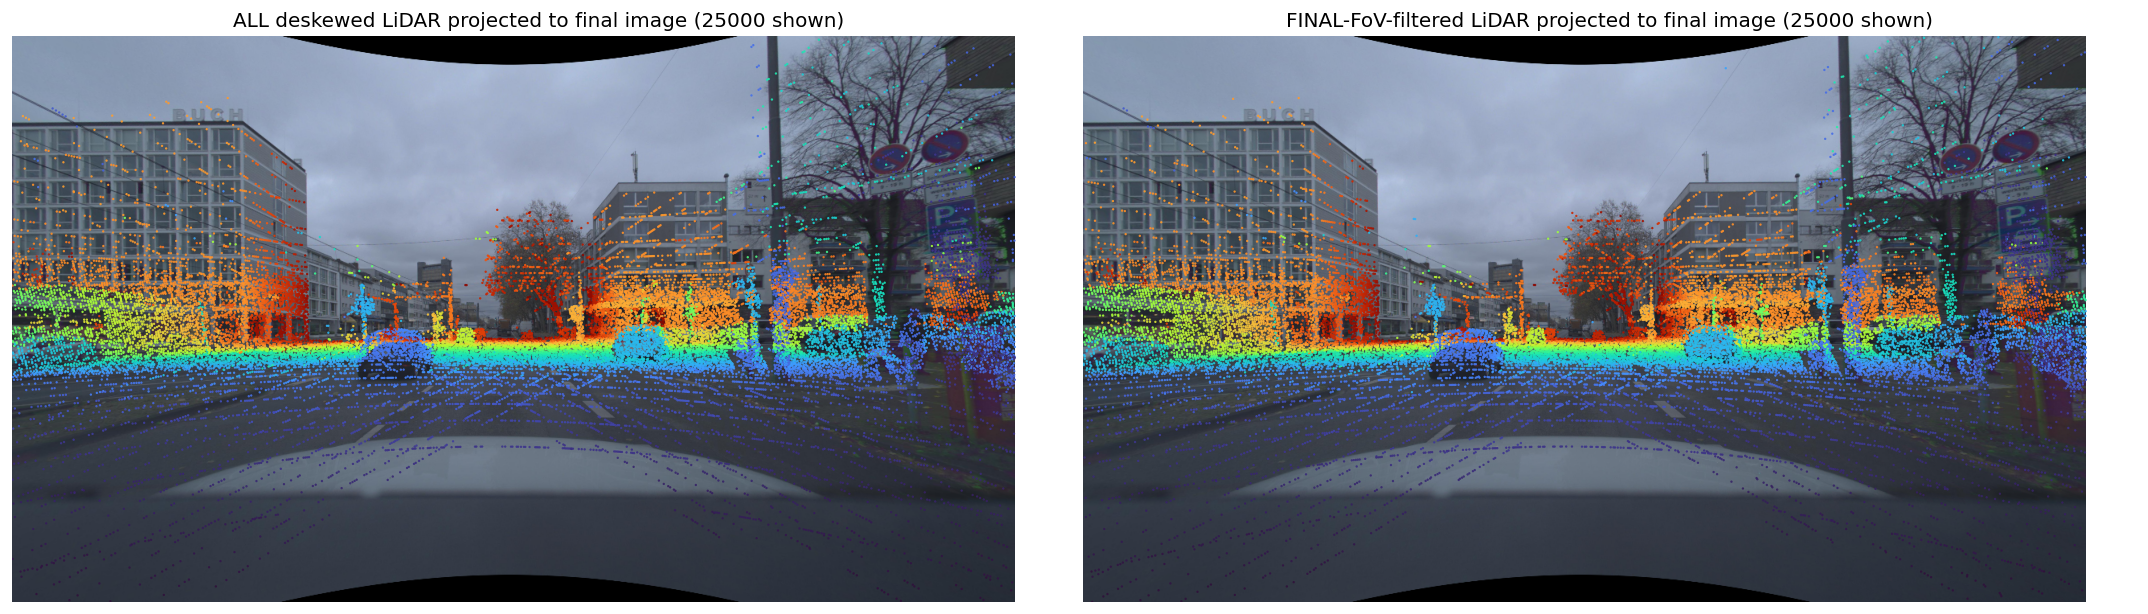

balance used for image undistortion: 0.3
new_K from OpenCV undistortion:
[[1.46751027e+03 0.00000000e+00 1.91068977e+03]
 [0.00000000e+00 1.46751027e+03 1.12323563e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
BEV_intrinsics used for projection:
[[475.94927621   0.         619.68316825]
 [  0.         476.53469967 364.74072247]
 [  0.           0.           1.        ]]
All projected total (inside final image): 73883
Final-FoV-filtered projected total: 73883


In [38]:
# ============================================================
# Visualize LiDAR projections on the FINAL undistorted + resized image
#
# This cell:
#   1) undistorts the raw front image using OpenCV fisheye
#   2) resizes it to the final training resolution
#   3) projects LiDAR points using the FINAL intrinsics
#   4) plots:
#        - all deskewed LiDAR points that land inside the image
#        - final-FoV-filtered LiDAR points
#
# Assumes the notebook already has:
#   - front_image              : raw front camera image
#   - calib
#   - points_cam               : ALL deskewed LiDAR points in camera frame
#   - fov_points_cam           : final-FoV-filtered LiDAR points in camera frame
#   - BEV_intrinsics           : final 3x3 intrinsics for undistorted+resized image
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt
from zod.constants import Camera

# ------------------------------------------------------------
# 0) User settings
# ------------------------------------------------------------
balance = 0.3          # set this to whatever choice you want to inspect
final_width = 1248
final_height = 704

# ------------------------------------------------------------
# 1) Build the FINAL undistorted + resized image
# ------------------------------------------------------------
cam_calib = calib.cameras[Camera.FRONT]

# Raw fisheye intrinsics/distortion from ZOD
K_raw = cam_calib.intrinsics[:3, :3].astype(np.float64)
D_raw = np.asarray(cam_calib.distortion, dtype=np.float64).reshape(-1, 1)

# Raw image size
raw_height, raw_width = front_image.shape[:2]

# OpenCV chooses a new virtual pinhole camera for the undistorted image.
# This depends on the chosen balance.
print("K_raw:\n", K_raw)
print("D_raw:\n", D_raw)
print("raw_width, raw_height:", raw_width, raw_height)
print("balance:", balance)
new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K_raw,
    D_raw,
    (raw_width, raw_height),
    np.eye(3),
    balance=balance,
)

# Build the remap from raw fisheye image -> undistorted image
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K_raw,
    D_raw,
    np.eye(3),
    new_K,
    (raw_width, raw_height),
    cv2.CV_16SC2,
)

# Undistort the raw image
undistorted_img = cv2.remap(
    front_image,
    map1,
    map2,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
)

# Resize the undistorted image to the final training resolution
final_image = cv2.resize(
    undistorted_img,
    (final_width, final_height),
    interpolation=cv2.INTER_LINEAR,
)

# ------------------------------------------------------------
# 2) Helper: project camera-frame 3D points using final intrinsics
# ------------------------------------------------------------
def project_points_camera_frame_to_xyd(points_cam, K):
    """
    Project camera-frame 3D points into image pixels using pinhole projection.

    Returns
    -------
    xyd : np.ndarray of shape (M, 3)
        [u, v, depth] for points with positive depth only
    """
    x = points_cam[:, 0]
    y = points_cam[:, 1]
    z = points_cam[:, 2]

    valid = z > 1e-6

    u = K[0, 0] * (x[valid] / z[valid]) + K[0, 2]
    v = K[1, 1] * (y[valid] / z[valid]) + K[1, 2]
    d = z[valid]

    return np.stack([u, v, d], axis=1)

# ------------------------------------------------------------
# 3) Project ALL deskewed LiDAR points in camera frame
# ------------------------------------------------------------
all_xyd = project_points_camera_frame_to_xyd(points_cam, BEV_intrinsics)

# Keep only points whose projected pixels land inside the final image
all_inside = (
    (all_xyd[:, 0] >= 0) & (all_xyd[:, 0] < final_width) &
    (all_xyd[:, 1] >= 0) & (all_xyd[:, 1] < final_height)
)
all_xyd = all_xyd[all_inside]

# ------------------------------------------------------------
# 4) Project FINAL-FoV-filtered LiDAR points in camera frame
# ------------------------------------------------------------
# These points already survived the earlier final FoV mask.
fov_xyd = project_points_camera_frame_to_xyd(fov_points_cam, BEV_intrinsics)

# Safety clip to final image bounds
fov_inside = (
    (fov_xyd[:, 0] >= 0) & (fov_xyd[:, 0] < final_width) &
    (fov_xyd[:, 1] >= 0) & (fov_xyd[:, 1] < final_height)
)
fov_xyd = fov_xyd[fov_inside]

# ------------------------------------------------------------
# 5) Display-only subsetting for readability
# ------------------------------------------------------------
def _display_subset(xyd, max_points=25000, min_depth=1.5, max_depth=60.0, seed=0):
    keep = (xyd[:, 2] >= min_depth) & (xyd[:, 2] <= max_depth)
    pts = xyd[keep]
    if pts.shape[0] > max_points:
        rng = np.random.default_rng(seed)
        pts = pts[rng.choice(pts.shape[0], size=max_points, replace=False)]
    return pts

all_pts = _display_subset(all_xyd, max_points=25000, seed=0)
fov_pts = _display_subset(fov_xyd, max_points=25000, seed=1)

# ------------------------------------------------------------
# 6) Plot side-by-side on the FINAL image
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(18, 7), dpi=120)

for ax, pts, title in [
    (axs[0], all_pts, f"ALL deskewed LiDAR projected to final image ({all_pts.shape[0]} shown)"),
    (axs[1], fov_pts, f"FINAL-FoV-filtered LiDAR projected to final image ({fov_pts.shape[0]} shown)"),
]:
    ax.imshow(final_image)

    if pts.shape[0] > 0:
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            c=pts[:, 2],
            s=2.0,
            cmap="turbo",
            alpha=0.9,
            linewidths=0,
        )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Summary
# ------------------------------------------------------------
print(f"balance used for image undistortion: {balance}")
print("new_K from OpenCV undistortion:")
print(new_K)
print("BEV_intrinsics used for projection:")
print(BEV_intrinsics)
print("All projected total (inside final image):", all_xyd.shape[0])
print("Final-FoV-filtered projected total:", fov_xyd.shape[0])

# Determining BEV grid size:

In [ ]:
# ============================================================
# BEV bounds from pedestrian 3D annotations (ZOD) 
# - Converts location_3d (LiDAR frame) -> EGO before stats
#MAKES SENSE TO REMOVE ANNOTTIONS OUTSIDE OF NEW FOV FIRST THOUGH! 
# THEN REDETERMINE BEV GRID SIZE
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from zod.data_classes.calibration import Calibration
from zod.constants import Lidar
from zod.utils.geometry import transform_points

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
MARGIN_METERS = 2.0
X_MAX_FIXED = 250.0
MAX_FRAMES = 20000      # set None for full dataset
PRINT_EVERY = 50        # heartbeat

DATASET_ROOT = Path("/home/edgelab/zod_dino_data/train2017")
print(f"DATASET_ROOT: {DATASET_ROOT}", flush=True)

# ------------------------------------------------------------
# DISCOVER FRAMES (unsorted for speed)
# ------------------------------------------------------------
frame_dirs = [
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir()
    and (p / "info.json").exists()
    and (p / "calibration.json").exists()
    and (p / "annotations" / "object_detection.json").exists()
]
if MAX_FRAMES is not None:
    frame_dirs = frame_dirs[:MAX_FRAMES]

print(f"Found frame dirs: {len(frame_dirs)}", flush=True)

# ------------------------------------------------------------
# ITERATE THROUGH DATASET
# ------------------------------------------------------------
rows = []
n_failed_frames = 0
n_total_objects = 0
n_ped_objects = 0
n_ped_with_3d = 0

# timing diagnostics
t_total_start = time.perf_counter()
t_calib_total = 0.0
t_ann_read_total = 0.0
t_ann_parse_total = 0.0
t_obj_loop_total = 0.0

pbar = tqdm(
    frame_dirs,
    desc="Scanning 3D ped annotations",
    miniters=1,
    mininterval=0.5,
    dynamic_ncols=True,
)

for i, frame_dir in enumerate(pbar, start=1):
    frame_id = frame_dir.name
    ann_path = frame_dir / "annotations" / "object_detection.json"
    calib_path = frame_dir / "calibration.json"

    frame_start = time.perf_counter()

    try:
        t0 = time.perf_counter()
        calib = Calibration.from_json_path(str(calib_path))
        T_lidar_to_ego = calib.lidars[Lidar.VELODYNE].extrinsics.transform
        t_calib_total += time.perf_counter() - t0

        t0 = time.perf_counter()
        ann_text = ann_path.read_text()
        t_ann_read_total += time.perf_counter() - t0

        t0 = time.perf_counter()
        anns = json.loads(ann_text)
        t_ann_parse_total += time.perf_counter() - t0

        if not isinstance(anns, list):
            n_failed_frames += 1
            continue

        t0 = time.perf_counter()
        for obj in anns:
            if not isinstance(obj, dict):
                continue
            props = obj.get("properties", {})
            if not isinstance(props, dict):
                continue

            n_total_objects += 1

            cls_l = str(props.get("class", "")).lower()
            typ_l = str(props.get("type", "")).lower()

            # Pedestrian filter
            if ("pedestrian" not in cls_l) and ("pedestrian" not in typ_l) and (cls_l != "person") and (typ_l != "person"):
                continue
            n_ped_objects += 1

            loc3d = props.get("location_3d")
            if not isinstance(loc3d, dict):
                continue
            coords = loc3d.get("coordinates")
            if not (isinstance(coords, (list, tuple)) and len(coords) >= 3):
                continue

            n_ped_with_3d += 1

            # location_3d is interpreted by ZOD as LiDAR frame -> convert to EGO
            pt_lidar = np.array(coords[:3], dtype=np.float32).reshape(1, 3)
            pt_ego = transform_points(pt_lidar, T_lidar_to_ego)[0]

            rows.append({
                "frame_id": frame_id,
                "x": float(pt_ego[0]),   # forward
                "y": float(pt_ego[1]),   # left/right
                "z": float(pt_ego[2]),   # up
            })
        t_obj_loop_total += time.perf_counter() - t0

    except Exception as e:
        n_failed_frames += 1
        tqdm.write(f"Failed on frame {frame_id}: {type(e).__name__}: {e}")

    frame_time = time.perf_counter() - frame_start

    pbar.set_postfix({
        "rows": len(rows),
        "ped3d": n_ped_with_3d,
        "fail": n_failed_frames,
        "sec/frame": f"{frame_time:.3f}",
    })

    if i % PRINT_EVERY == 0:
        elapsed = time.perf_counter() - t_total_start
        avg_per_frame = elapsed / i
        tqdm.write(
            f"[{i}/{len(frame_dirs)}] rows={len(rows)} "
            f"objs={n_total_objects} ped={n_ped_objects} ped_3d={n_ped_with_3d} "
            f"failed_frames={n_failed_frames} elapsed={elapsed:.1f}s "
            f"avg_per_frame={avg_per_frame:.3f}s"
        )

# final timing breakdown
elapsed_total = time.perf_counter() - t_total_start
print("\n=== Timing breakdown ===", flush=True)
print(f"Total elapsed:           {elapsed_total:.2f} s", flush=True)
print(f"Calibration load total: {t_calib_total:.2f} s", flush=True)
print(f"Annotation read total:  {t_ann_read_total:.2f} s", flush=True)
print(f"Annotation parse total: {t_ann_parse_total:.2f} s", flush=True)
print(f"Object loop total:      {t_obj_loop_total:.2f} s", flush=True)

# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------
df = pd.DataFrame(rows)

print("\n=== Scan summary ===", flush=True)
print(f"Total objects scanned:        {n_total_objects}", flush=True)
print(f"Pedestrian objects found:     {n_ped_objects}", flush=True)
print(f"Pedestrian objects with 3D:   {n_ped_with_3d}", flush=True)
print(f"Frames failed during parse:   {n_failed_frames}", flush=True)
print(f"Total pedestrian 3D rows:     {len(df)}", flush=True)

if df.empty:
    raise RuntimeError("No pedestrian 3D annotations collected.")

# ------------------------------------------------------------
# COMPUTE DISTRIBUTION STATISTICS
# ------------------------------------------------------------
abs_y = np.abs(df["y"].to_numpy())

stats = {
    "x_min": float(df["x"].min()),
    "x_max": float(df["x"].max()),
    "x_p99": float(np.percentile(df["x"], 99)),
    "x_p999": float(np.percentile(df["x"], 99.9)),
    "y_min": float(df["y"].min()),
    "y_max": float(df["y"].max()),
    "abs_y_max": float(abs_y.max()),
    "abs_y_p99": float(np.percentile(abs_y, 99)),
    "abs_y_p999": float(np.percentile(abs_y, 99.9)),
    "abs_y_p9995": float(np.percentile(abs_y, 99.95)),
}

print("\n=== Pedestrian center statistics (EGO frame) ===", flush=True)
for k, v in stats.items():
    print(f"{k:15s}: {v:9.3f}", flush=True)

# ------------------------------------------------------------
# RECOMMENDED BEV BOUNDS
# ------------------------------------------------------------
y_bound_strict = stats["abs_y_max"] + MARGIN_METERS
y_bound_robust = stats["abs_y_p999"] + MARGIN_METERS

print("\n=== Suggested BEV bounds ===", flush=True)
print("\nStrict bounds (include everything):", flush=True)
print(f"x: [0, {X_MAX_FIXED}]", flush=True)
print(f"y: [-{y_bound_strict:.1f}, {y_bound_strict:.1f}]", flush=True)

print("\nRobust bounds (99.9% coverage):", flush=True)
print(f"x: [0, {X_MAX_FIXED}]", flush=True)
print(f"y: [-{y_bound_robust:.1f}, {y_bound_robust:.1f}]", flush=True)

# ------------------------------------------------------------
# VISUALIZE DISTRIBUTION
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["x"], df["y"], s=1, alpha=0.25)
plt.xlabel("x forward (m)")
plt.ylabel("y left (m)")
plt.title("Pedestrian 3D centers in EGO frame (x vs y)")
plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.grid(True, alpha=0.3)
plt.show()

# BEV-style plot: forward up
plt.figure(figsize=(8, 8))
plt.scatter(-df["y"], df["x"], s=1, alpha=0.25)
plt.xlabel("-y (screen left/right)")
plt.ylabel("x forward (up)")
plt.title("Pedestrian centers (BEV-style display)")
plt.axvline(0, color="black", linewidth=1)
plt.axhline(0, color="black", linewidth=1)
plt.gca().set_aspect("equal", "box")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# BEV GRID SIZE ESTIMATE
# ------------------------------------------------------------
def grid_size(x_range, y_range, resolution):
    x_cells = int((x_range[1] - x_range[0]) / resolution)
    y_cells = int((y_range[1] - y_range[0]) / resolution)
    return x_cells, y_cells, x_cells * y_cells

print("\n=== BEV grid sizes (robust y-bound) ===", flush=True)
for res in [0.25, 0.5, 1.0]:
    gx, gy, cells = grid_size((0, X_MAX_FIXED), (-y_bound_robust, y_bound_robust), res)
    print(f"Resolution {res:.2f} m -> grid {gx} x {gy} ({cells/1e6:.2f}M cells)", flush=True)

DATASET_ROOT: /home/edgelab/zod_dino_data/train2017


KeyboardInterrupt: 

### SAVE OUTPUTS TO USE FOR BEVFUSION:


In [15]:
out = Path("/home/edgelab/multimodal-MoE/outputs/tmp")
out.mkdir(parents=True, exist_ok=True)

# save your already prepared point cloud
np.save(out / "fov_points_cam_xyzi.npy", fov_points_cam_xyzi.astype(np.float32))
print("saved:", out / "fov_points_cam_xyzi.npy", fov_points_cam_xyzi.shape)

saved: /home/edgelab/multimodal-MoE/outputs/tmp/fov_points_cam_xyzi.npy (81286, 4)
